In [1]:
%load_ext autoreload
%autoreload 2

# Reading calibrated sMOMENT parameters and applying them to the models

This script reads the outputs from the model calibration in Matlab. These outputs represent the change factors original kcats and protein pool variables need to be multiplied with.

In [2]:
import cobra
import pandas
import numpy as np
import json
import matplotlib.pyplot as plt

## 1) Read uncalibrated models and protein pools

In [3]:
smoment_models_dict = {
    'Mitocore_Preliminary': './../autopacmen_output/Mitocore_Preliminary/Mitocore_Preliminary_uncalibrated.xml',
    'Mitocore_MitoMammal': './../autopacmen_output/Mitocore_MitoMammal/Mitocore_MitoMammal_uncalibrated.xml',
    'Mitocore_aligned_to_Human1': './../autopacmen_output/Mitocore_aligned_to_Human1/Mitocore_aligned_to_Human1_uncalibrated.xml',
}

model_files = {}

for model_name in smoment_models_dict.keys():
    model_files[model_name] = {
        "kcat_mapping_path": f"./../autopacmen_output/{model_name}/{model_name}_reactions_kcat_mapping_combined.json",
        "calibrated_model_path": f"./../autopacmen_output/{model_name}/{model_name}_calibrated.xml",
        "protein_file_output": f'../model_data_input/{model_name}_protein_data',
        "mol_masses_mapping": f'../model_data_input/{model_name}_protein_id_mass_mapping.json',
        "calibrated_kcats_xlsx": f'./../autopacmen_output/{model_name}/{model_name}_kcats_calibrated.xlsx'
    }

In [4]:
original_kcats = {}

for model_name in smoment_models_dict.keys():
    with open(model_files[model_name]["kcat_mapping_path"]) as file:
        original_kcats[model_name] = json.load(file)

In [5]:
from utilities.utils import get_default_kcat

# get default kcat
# kcat is in 1/s, in model in 1/h
default_kcats = {}

for model_name in smoment_models_dict.keys():
    default_kcats[model_name] = get_default_kcat(original_kcats[model_name], 'median')
    print(f'{model_name} median kcat: ', default_kcats[model_name])

Mitocore_Preliminary median kcat:  11.7
Mitocore_MitoMammal median kcat:  11.85
Mitocore_aligned_to_Human1 median kcat:  9.95


## 2) Read calibrated parameters

In [6]:
# read change factors
with open('./../autopacmen_output/calibrated_factors.json') as file:
    calibrated_params = json.load(file)

In [7]:
calibrated_params

{'Mitocore_Preliminary': {'reactions': {'R_CV_MitoCore_GPRSPLIT_3_TG_forward': 18.39217219539137,
   'R_CV_MitoCore_GPRSPLIT_1_TG_forward': 18.39217219539137,
   'R_CV_MitoCore_GPRSPLIT_2_TG_forward': 18.39217219539137,
   'R_CI_MitoCore_GPRSPLIT_1_TG_forward': 50.271597983165954,
   'R_PDHm_GPRSPLIT_1': 39.08584838682158,
   'R_ACONTm_GPRSPLIT_1_TG_forward': 50.27158667096669,
   'R_ACONT_GPRSPLIT_1_TG_forward': 50.27158689285316,
   'R_SUCOASm_GPRSPLIT_1_TG_reverse': 50.271569239031834,
   'R_GHMT2r_GPRSPLIT_1_TG_forward': 50.271586022984536,
   'R_MCOATA_GPRSPLIT_1_TG_forward': 50.271586876361134,
   'R_CIII_MitoCore_GPRSPLIT_1_TG_forward': 50.27156992277682,
   'R_CIV_MitoCore_GPRSPLIT_1': 50.27158638559078,
   'R_ICDHxm_GPRSPLIT_1': 50.271586679558865},
  'bestPool': 0.11,
  'newObjectiveVal': 2.1943661918793134},
 'Mitocore_MitoMammal': {'reactions': {'R_CV_MitoCore_GPRSPLIT_1_TG_forward': 18.392172126689694,
   'R_CV_MitoCore_GPRSPLIT_2_TG_forward': 18.392172126689694,
   'R_CV_

### 2.1) Get calibrated protein pools

In [8]:
# read original pool variables
prot_pool_dict = {'model': [], 'original_pool': [], 'calibrated_pool': []}

for model_name, path in smoment_models_dict.items():

    model = cobra.io.read_sbml_model(path)

    prot_pool_dict['model'].append(model_name)
    prot_pool_dict['original_pool'].append(model.reactions.ER_pool_TG_.upper_bound)

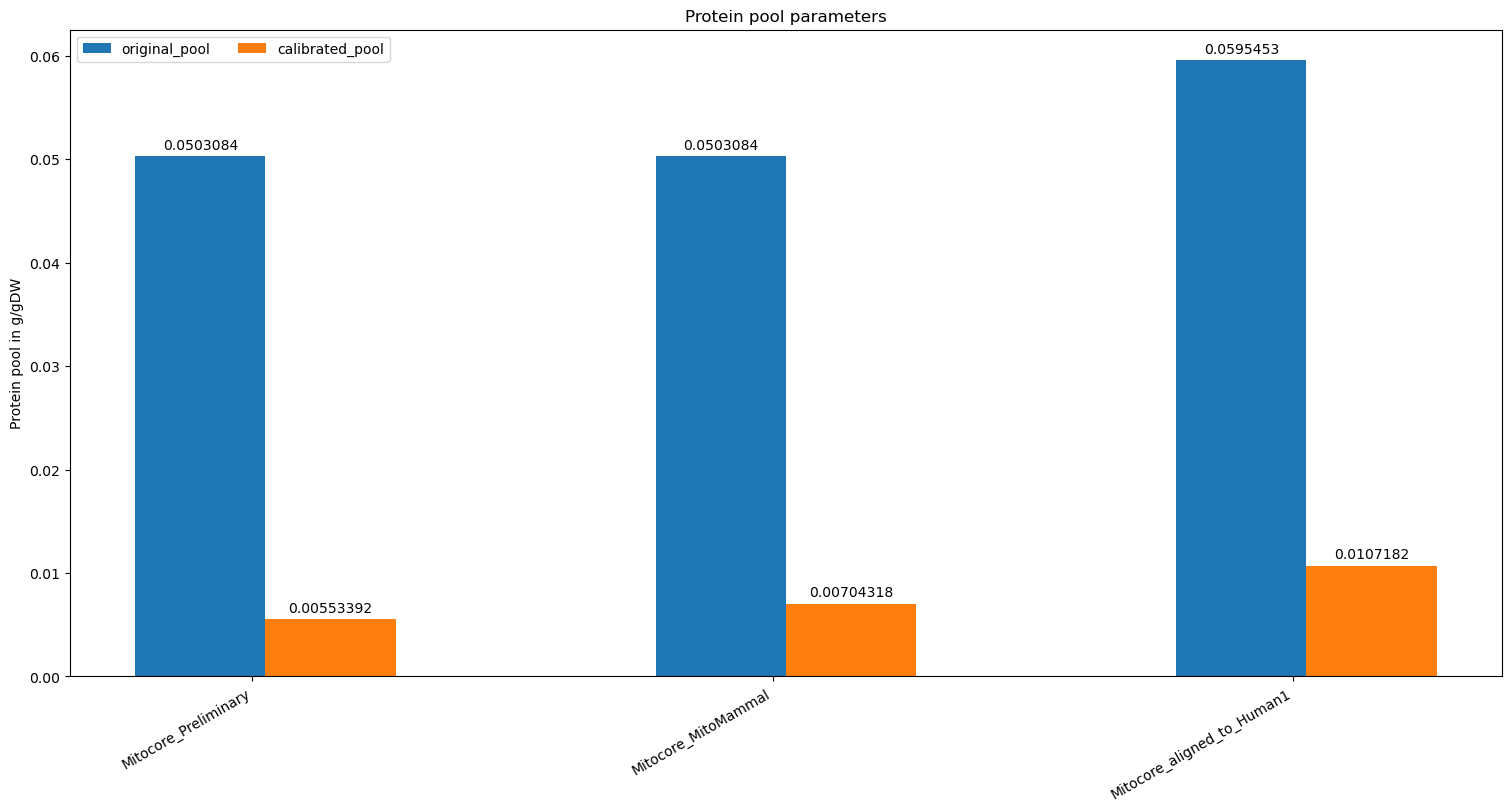

In [9]:
# plot the original vs calibrated pools
for model_index, model_name in enumerate(prot_pool_dict['model']):

    pool_stoichiometry = calibrated_params[model_name]['bestPool']

    new_pool = prot_pool_dict['original_pool'][model_index] * pool_stoichiometry

    prot_pool_dict['calibrated_pool'].append(new_pool)

# plot protein pools
models = prot_pool_dict['model']
x_positions = np.arange(len(models))
values = {key : prot_pool_dict[key] for key in ['original_pool', 'calibrated_pool']}

width = 0.25  # the width of the bars
multiplier = 0.1

fig, ax = plt.subplots(layout='constrained')
fig.set_size_inches(15, 8)

for key, value in values.items():
    offset = width * multiplier
    rects = ax.bar(x_positions + offset, value, width, label=key)
    ax.bar_label(rects, padding=3)
    multiplier += 1

ax.tick_params(axis='x', labelrotation=45)
ax.set_ylabel('Protein pool in g/gDW')
ax.set_title('Protein pool parameters')
ax.set_xticks(x_positions + width/2, models)
ax.legend(loc='upper left', ncols=3)
# ax.set_ylim(0, 0.015)
fig.autofmt_xdate()

plt.show()

### 2.2) Get calibrated kcats

In [10]:
# create a matrix for every reaction that has been calibrated
# rows original reaction name (forward or reverse)
# columns original kcats, one column for every model

# some reactions have no kcat assigned, autoPACMEN automatically
# uses a default kcat (e.g., median) --> in the original kcats 
# there won't be a value and in the model_kcats_df a nan value

# reaction id additions:
# _GPRSPLIT_ is added to every reaction beeing split
# _TG_ is added to every reversible reaction

import re

model_data = {}

for model in calibrated_params.keys():

    model_kcats_dict = {'original_reactions': [], 'original_kcats': [], 'model_kcats': []}

    for reaction, factor in calibrated_params[model]['reactions'].items():

        reaction_id = re.sub('^R_','', reaction)
        original_reaction_id = reaction_id.split('_TG_')[0].split('_GPRSPLIT_')[0]

        original_reaction_kcats = original_kcats[model][original_reaction_id]

        directions = ['forward', 'reverse']
        if '_TG_' in reaction_id:
            directions = [reaction_id.split('_TG_')[1]]

        for direction in directions:
            original_kcat = original_reaction_kcats[direction]

            if str(original_kcat) == 'nan':
                original_kcat = default_kcats[model]

            model_kcats_dict['original_reactions'].append(original_reaction_id + "_" + direction)
            model_kcats_dict['original_kcats'].append(original_kcat)
            model_kcats_dict['model_kcats'].append(original_kcat*factor)
    
    model_kcats_df = pandas.DataFrame.from_dict(model_kcats_dict).drop_duplicates()
    model_kcats_df = model_kcats_df.set_index('original_reactions')
    model_data[model] = model_kcats_df

In [11]:
for model_name in smoment_models_dict.keys():
    pandas.DataFrame.to_excel(model_data[model_name], model_files[model_name]["calibrated_kcats_xlsx"])

# 3) Apply change factors to stoichiometric coefficients in model

In [12]:
from utilities.utils import apply_kcats_to_model

# iterate through models
for model_id, model_path in smoment_models_dict.items():
    
    if model_id not in calibrated_params.keys():
        continue

    calibrated_prot_pool = calibrated_params[model_id]['bestPool']
    calibration_factors = calibrated_params[model_id]['reactions']

    calibrated_model = apply_kcats_to_model(model_id, model_path, calibrated_prot_pool, calibration_factors)

    # write calibrated model
    model_output_path = model_files[model_id]['calibrated_model_path']

    cobra.io.write_sbml_model(calibrated_model, model_output_path)



Scaling Mitocore_Preliminary
Scaled protein pool to {<Metabolite prot_pool at 0x1af664d0eb0>: 0.11}

Scaled CV_MitoCore_GPRSPLIT_3_TG_forward from 
CV_MitoCore_GPRSPLIT_3_TG_forward: 1.5015015015015e-05 ENZYME_ENSG00000099624 + 1.5015015015015e-05 ENZYME_ENSG00000110955 + 1.5015015015015e-05 ENZYME_ENSG00000116459 + 1.5015015015015e-05 ENZYME_ENSG00000124172 + 1.5015015015015e-05 ENZYME_ENSG00000152234 + 1.5015015015015e-05 ENZYME_ENSG00000154723 + 1.5015015015015e-05 ENZYME_ENSG00000165629 + 1.5015015015015e-05 ENZYME_ENSG00000167283 + 1.5015015015015e-05 ENZYME_ENSG00000167863 + 1.5015015015015e-05 ENZYME_ENSG00000169020 + 1.5015015015015e-05 ENZYME_ENSG00000198899 + 1.5015015015015e-05 ENZYME_ENSG00000228253 + 1.5015015015015e-05 ENZYME_ENSG00000241468 + 1.5015015015015e-05 ENZYME_ENSG00000241837 + 2.7 PMF_c + adp_m + h_m + pi_m + 0.00517507507507507 prot_pool --> 2.7 PMF_m + armm_CV_MitoCore_forward + atp_m + h2o_m to 
CV_MitoCore_GPRSPLIT_3_TG_forward: 8.163807328194434e-07 ENZY